# 4.2.2 周期振幅与相位的测量

## 学习目标与先修知识

能明确暂态（transient）窗口、峰值和过零规则，计算振幅（amplitude）与周期，分开采样误差、动力学暂态和扰动后的相位（phase）差。

先修：上一节径向振子的解析周期与极限环（limit cycle）；列表下标和线性插值。 [复习上一节](01-阻尼受迫与自维持振荡.ipynb)。

## 具体问题

测到两次“心跳峰”之间的间隔，就能宣布系统的长期周期吗？用已知周期的理想节律校验测量方法，再考察平台峰、短窗口和相位扰动。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
values=[0,1,0,-1,0,1,0,-1,0]
peak_indices=[i for i in range(1,len(values)-1) if values[i]>values[i-1] and values[i]>values[i+1]]
print('峰下标',peak_indices,'；采样间隔 0.5 时峰间隔为',(.5*(peak_indices[-1]-peak_indices[0])))

峰下标 [1, 5] ；采样间隔 0.5 时峰间隔为 2.0


## 模型假设

沿用 μ=0.5、ω=1 的无量纲（dimensionless）径向振子，初始 [0.05,0]；解析周期 2π。x 是观测（observation）变量，R 是状态（state）半径，二者不能混作同一个振幅统计量。

峰值法：窗口从下标 start 开始，端点不作为峰，只保留同时严格大于两个邻点的内点；平台峰不记录。振幅用窗口内 (max−min)/2。过零法：仅记录从非正到正的片段，线性插值，连续零平台只在最后的零接到正值时计一次。至少两个事件才计算平均周期，否则保留 None。

## 数学解释与推导

均匀采样 t_i=iΔt。严格峰值规则要求一个点高于左右邻点，因此两个相邻等高点形成的平台峰会被略过。

向上过零可以更精细地定位事件。在 x_i≤0<x_(i+1) 的片段中，用直线近似
$$t_\text{cross}=\left(i-\frac{x_i}{x_{i+1}-x_i}\right)\Delta t.$$
分母此时严格为正。只看同方向事件，才不会将正弦波的半周期误记成整周期。若有 m≥2 个事件，平均相邻间隔为 (t_last−t_first)/(m−1)。截掉暂态不会改变原时刻坐标，不能把事件时间重新从零算起。

暂态改变波的形状和幅度；采样限制峰的位置。这是不同误差。对同一解析轨迹（trajectory）改变 Δt 检查采样误差，对同一 Δt 改变截断时间检查暂态。接近临界参数（parameter）时恢复很慢，不能给所有模型（model）套一个固定“前十秒都不要”的经验规则。

相位是轨道中的位置。稳定极限环吸引邻近半径，并不自动对齐相位。对本例 θ′=ω，两条轨迹的相位差满足 Δθ′=0；一次改变角度的扰动可以留下永久相位差，即使半径已经恢复。

## 核心实现

将推导中的每一步明确写成计算。

In [3]:
def radial_exact(mu,omega,initial,times):
    square=initial[0]**2+initial[1]**2
    if square==0:return [[0.,0.] for _ in times]
    states=[]
    for t in times:
        if mu==0:
            radius_square=square/(1+2*square*t)
        else:
            exponent=math.exp(2*mu*t)
            radius_square=square*exponent/(1+square*math.expm1(2*mu*t)/mu)
        scale=math.sqrt(radius_square/square)
        cosine,sine=math.cos(omega*t),math.sin(omega*t)
        states.append([scale*(initial[0]*cosine-initial[1]*sine),scale*(initial[0]*sine+initial[1]*cosine)])
    return states

def peak_summary(values,dt,start):
    tail=values[start:]
    amplitude=(max(tail)-min(tail))/2
    peaks=[i*dt for i in range(start+1,len(values)-1) if values[i]>values[i-1] and values[i]>values[i+1]]
    period=(peaks[-1]-peaks[0])/(len(peaks)-1) if len(peaks)>=2 else None
    return amplitude,peaks,period

def crossing_summary(values,dt,start):
    crossings=[]
    for i in range(start,len(values)-1):
        if values[i]<=0<values[i+1]:
            crossings.append((i-values[i]/(values[i+1]-values[i]))*dt)
    period=(crossings[-1]-crossings[0])/(len(crossings)-1) if len(crossings)>=2 else None
    return crossings,period

## 对照实验

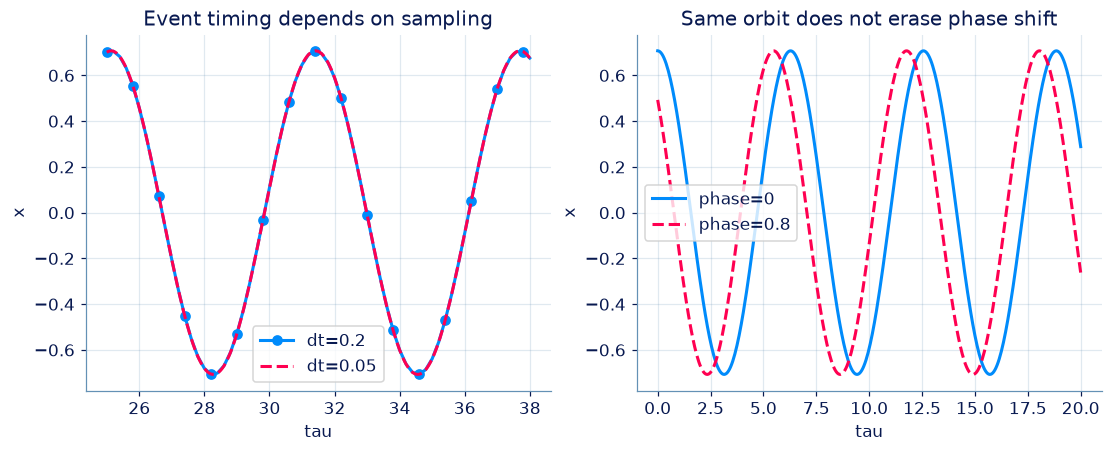

| Δt | 半峰峰值 | 峰法周期 | 过零周期 | 解析周期 |
| --- | --- | --- | --- | --- |
| 0.2 | 0.707048 | 6.26667 | 6.28313 | 6.28319 |
| 0.05 | 0.707097 | 6.28333 | 6.28319 | 6.28319 |

In [4]:
rows=[]
fig,axes=plt.subplots(1,2,figsize=(10,4))
for dt,color,style in [(.2,BLUE,'o-'),(.05,PINK,'--')]:
    times=np.arange(round(40/dt)+1)*dt
    states=np.array(radial_exact(.5,1,[.05,0],times))
    start=round(15/dt)
    amplitude,peaks,peak_period=peak_summary(states[:,0],dt,start)
    crosses,cross_period=crossing_summary(states[:,0],dt,start)
    rows.append((dt,amplitude,peak_period,cross_period,2*np.pi))
    mask=(times>=25)&(times<=38)
    axes[0].plot(times[mask],states[mask,0],style,color=color,markevery=4,label=f'dt={dt}')
times=np.linspace(0,20,401)
for angle,color,style in [(0,BLUE,'-'),(.8,PINK,'--')]:
    init=[np.sqrt(.5)*np.cos(angle),np.sqrt(.5)*np.sin(angle)]
    axes[1].plot(times,np.array(radial_exact(.5,1,init,times))[:,0],color=color,ls=style,label=f'phase={angle}')
axes[0].set(xlabel='tau',ylabel='x',title='Event timing depends on sampling')
axes[1].set(xlabel='tau',ylabel='x',title='Same orbit does not erase phase shift')
for ax in axes:ax.legend()
plt.show()
display(Markdown(show_table(['Δt','半峰峰值','峰法周期','过零周期','解析周期'],rows)))

## 结果解释

两种采样对同一条解析轨迹测量，较密采样通常更接近解析周期；峰值时刻只能落在网格上，插值过零可减少这项误差，但它仍受波形和采样影响。右图半径相同却保留相位差。

把暂态截断改成 0，再看振幅估计；再把 Δt 增大到接近半周期。应分别说明是动力学还没稳定，还是观测过稀，而不是统一称为“模型不准”。

### 独立核对

先用能手算的四点、平台输入（input）检查规则，再用与振子求解无关的 sin(t) 检查已知周期。

In [5]:
assert peak_summary([0,1,0,-1,0,1,0],.5,0)==(1.,[.5,2.5],2.)
assert peak_summary([0,1,1,0],1,0)[2] is None
assert crossing_summary([-1,1,-1,1],1,0)==([.5,2.5],2.)
assert crossing_summary([-1,0,0,1],1,0)==([2.],None)
times=np.arange(10001)*.01
crosses,period=crossing_summary(np.sin(times),.01,1000)
assert abs(period-2*np.pi)<1e-5
print('手算事件、平台边界与已知正弦周期通过。')

手算事件、平台边界与已知正弦周期通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/04-02-自维持振荡与极限环/explore/)：先预测条件变化的后果，再用交互对照本节推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：在明确峰值规则下测量周期

输入（input）等间隔观测（observation）值。截去前段后计算半峰峰值振幅（amplitude），以及严格局部峰之间的平均间隔。平台峰和端点不记作峰。

**函数与代码模板**

```python
def solve(
    values: list[float],
    dt: float,
    start: int,
) -> tuple[float, list[float], float | None]:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 时刻 i*dt 的观测值。 | 1 |
| `dt` | `float` | 采样间隔。 | 1 |
| `start` | `int` | 保留窗口的首个下标，包含该值。 | 1 |

**返回值**

按以下顺序返回元组：(amplitude, peak_times, mean_period)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `amplitude` | `float` | 窗口内 (最大值−最小值)/2。 | 1 |
| `peak_times` | `list[float]` | 满足严格峰值条件的时刻。 | 1 |
| `mean_period` | <code>float &#124; None</code> | 至少两个峰时返回相邻峰间隔均值，否则 None。 | 1 |

**计算规则**

振幅使用 values[start:]。峰下标为 start+1≤i≤len(values)−2，且 values[i] 同时严格大于两邻点。至少两个峰时 period=(最后峰时刻−首峰时刻)/(峰数−1)。

**约束与边界**

- 所有输入数值有限；不修改输入列表。
- 3≤len(values)≤5000；0≤start≤len(values)−3；0<dt≤2；值的绝对值≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| values | 时刻 i*dt 的观测值。 | [0, 1, 0, -1, 0, 1, 0, -1, 0] | 1 |
| dt | 采样间隔。 | 0.5 | 1 |
| start | 保留窗口的首个下标，包含该值。 | 0 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
values = [0, 1, 0, -1, 0, 1, 0, -1, 0]
dt = 0.5
start = 0

result = solve(values, dt, start)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| amplitude | 窗口内 (最大值−最小值)/2。 | 1 | 1 |
| peak_times | 满足严格峰值条件的时刻。 | [0.5, 2.5] | 1 |
| mean_period | 至少两个峰时返回相邻峰间隔均值，否则 None。 | 2 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.0, [0.5, 2.5], 2.0)
```

**样例解释**

峰在下标 1 和 5，即时刻 0.5 和 2.5；振幅为 1，平均周期为 2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：在明确峰值规则下测量周期](http://127.0.0.1:8000/chapters/04-02-%E8%87%AA%E7%BB%B4%E6%8C%81%E6%8C%AF%E8%8D%A1%E4%B8%8E%E6%9E%81%E9%99%90%E7%8E%AF/practice/?question=p04-peak-period)

### 第 2 题 · Python 计算题：用向上过零估计周期

对等间隔轨迹（trajectory）做分段直线插值，找向上过零时刻。重复零值只在最后一个零接到正值的片段计一次。

**函数与代码模板**

```python
def solve(
    values: list[float],
    dt: float,
    start: int,
) -> tuple[list[float], float | None]:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 时刻 i*dt 的观测（observation）值。 | 1 |
| `dt` | `float` | 采样间隔。 | 1 |
| `start` | `int` | 开始检查的片段左端下标。 | 1 |

**返回值**

按以下顺序返回元组：(crossings, mean_period)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `crossings` | `list[float]` | 按时间顺序排列的向上过零时刻。 | 1 |
| `mean_period` | <code>float &#124; None</code> | 至少两次过零时的平均间隔，否则 None。 | 1 |

**计算规则**

对 i=start,...,len(values)−2，若 values[i]≤0<values[i+1]，记录 (i−values[i]/(values[i+1]−values[i]))*dt。两次以上按首末间隔平均。

**约束与边界**

- 所有输入（input）数值有限；不修改输入列表。
- 2≤len(values)≤5000；0≤start≤len(values)−2；0<dt≤2；值的绝对值≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| values | 时刻 i*dt 的观测（observation）值。 | [-1, 1, -1, 1] | 1 |
| dt | 采样间隔。 | 1 | 1 |
| start | 开始检查的片段左端下标。 | 0 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
values = [-1, 1, -1, 1]
dt = 1
start = 0

result = solve(values, dt, start)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| crossings | 按时间顺序排列的向上过零时刻。 | [0.5, 2.5] | 1 |
| mean_period | 至少两次过零时的平均间隔，否则 None。 | 2 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.5, 2.5], 2.0)
```

**样例解释**

两个过零时刻为 0.5 和 2.5，平均间隔为 2；使用插值而不是直接取右端采样时刻。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：用向上过零估计周期](http://127.0.0.1:8000/chapters/04-02-%E8%87%AA%E7%BB%B4%E6%8C%81%E6%8C%AF%E8%8D%A1%E4%B8%8E%E6%9E%81%E9%99%90%E7%8E%AF/practice/?question=p04-crossing-period)

### 第 3 题 · 多项选择题：回到圆环等于回到原来的时钟吗

径向振子已在稳定极限环（limit cycle）上。扰动改变了半径和角度，之后恢复原方程。哪些成立？

- **A.** 半径可恢复到同一极限环。
- **B.** 角度变化一定自动消失。
- **C.** 本模型（model） θ′=ω，两条轨迹（trajectory）的相位（phase）差保持不变。
- **D.** 轨道吸引与逐点同步是不同结论。

[作答：回到圆环等于回到原来的时钟吗](http://127.0.0.1:8000/chapters/04-02-%E8%87%AA%E7%BB%B4%E6%8C%81%E6%8C%AF%E8%8D%A1%E4%B8%8E%E6%9E%81%E9%99%90%E7%8E%AF/practice/?question=p04-phase-after-kick)

### 第 4 题 · 单项选择题：周期数值相同就足够了吗

一段短轨迹（trajectory）仅包含两个很早的峰。计算得到一个峰间周期。哪个后续检查最合适？

- **A.** 延长观察、增加暂态（transient）截断并细化采样，与模型（model）的解析周期比较。
- **B.** 把输出（output）小数位增多即可提高可信度。
- **C.** 只需删除振幅（amplitude）较小的峰，不说明规则。
- **D.** 直接把它宣布为长期极限环（limit cycle）周期。

[作答：周期数值相同就足够了吗](http://127.0.0.1:8000/chapters/04-02-%E8%87%AA%E7%BB%B4%E6%8C%81%E6%8C%AF%E8%8D%A1%E4%B8%8E%E6%9E%81%E9%99%90%E7%8E%AF/practice/?question=p04-measurement-window)